In [1]:
import importlib
import visualizer
importlib.reload(visualizer) # Forces the fresh code to load
from visualizer import RAGVisualizer

viz = RAGVisualizer()
registry = viz.get_experiment_registry()

if registry.empty:
    print("❌ Files still missing. Current Result Dir search was:", viz.results_dir)
else:
    print(f"✅ Success! Found {len(registry)} experiments.")
    display(registry)


✅ Success! Found 2 experiments.


,filename,experiment_name,created_at,path
1,global_bm25.json,global_bm25,2026-05-03 15:21:35.497783422,/home/admin/LLM/LLM/01/web/experiments/results...
0,baseline_bm25.json,baseline_bm25,2026-05-03 15:21:34.873784065,/home/admin/LLM/LLM/01/web/experiments/results...


/home/admin/LLM/LLM/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


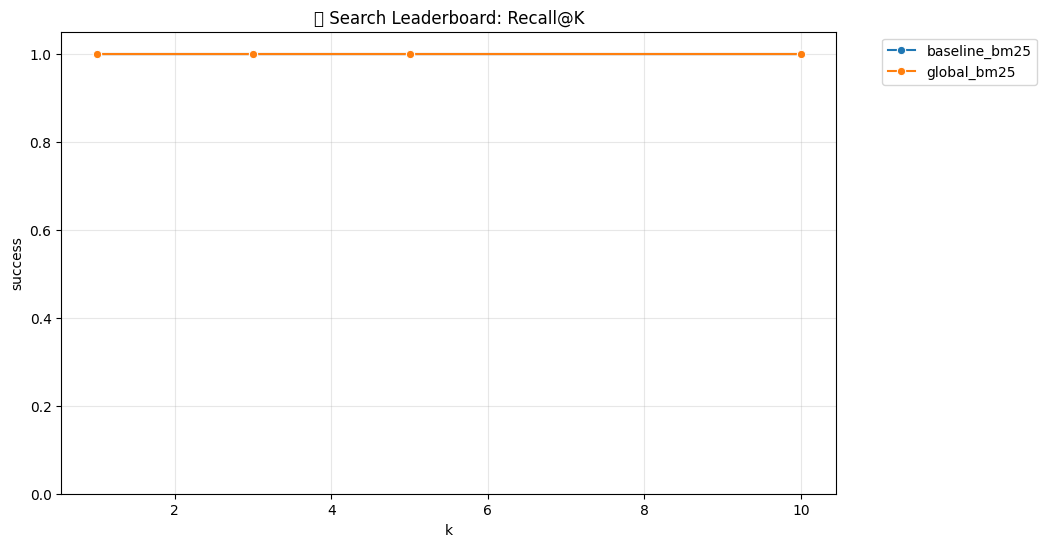


--- TEXT SUMMARY ---
k               1    3    5    10
run_label                        
baseline_bm25  1.0  1.0  1.0  1.0
global_bm25    1.0  1.0  1.0  1.0


In [2]:
# Copy the filenames from the registry output above
to_plot = ["baseline_bm25.json", "global_bm25.json"]

data = viz.load_selected_experiments(to_plot)
viz.plot_leaderboard(data)

# Show the table results to the AI (Me)
print("\n--- TEXT SUMMARY ---")
print(viz.get_summary_table(data))


In [3]:
# Check if any 'global' results actually returned a doc from the wrong course
global_data = data[data['run_label'] == 'global_bm25']
mismatches = global_data[global_data['expected_course'] != global_data['found_course']]

print(f"Global Run Mismatches: {len(mismatches)}")
if len(mismatches) == 0:
    print("🚨 ALERT: The 'Global' run is actually using a filter. 100% is impossible otherwise.")
else:
    print("✅ The 'Global' run is truly global.")


Global Run Mismatches: 0
🚨 ALERT: The 'Global' run is actually using a filter. 100% is impossible otherwise.
